In [70]:
dnd5rulebooklink = "https://ordempendragon.wordpress.com/wp-content/uploads/2017/04/dd-5e-livro-do-jogador-fundo-branco-biblioteca-c3a9lfica.pdf"

import requests

# Link do PDF e caminho local para salvar
pdf_url = "https://ordempendragon.wordpress.com/wp-content/uploads/2017/04/dd-5e-livro-do-jogador-fundo-branco-biblioteca-c3a9lfica.pdf"
pdf_path = "dd5e_livro_jogador.pdf"
output_md_path = "spells_dnd5e.md"

# Baixar o PDF
response = requests.get(pdf_url)
with open(pdf_path, "wb") as f:
    f.write(response.content)


In [128]:
from PyPDF2 import PdfReader

# Caminhos
pdf_path = "dd5e_livro_jogador.pdf"
output_md_path = "spells_dnd5e.md"
output_json_path = "spells_dnd5e.json"

# Ler o PDF
reader = PdfReader(pdf_path)

# Extrair o texto cru
extracted_text = ""
spells_pages = []

start_page = 212
end_page = 288

# using this range
# notes para o markdown as paginas com magias estao no intervalo 213-288 de paginas por isso foi necessario usar esse range
for i in range(start_page, end_page):  # 213-288 inclusive
    page = reader.pages[i]
    text = page.extract_text()
    if text:
        text = text.strip()
        extracted_text += text + "\n\n"

with open(output_md_path, "w", encoding="utf-8") as f:
    f.write(extracted_text)

print("Arquivos salvos sem formatação extra.")


Arquivos salvos sem formatação extra.


In [129]:
import re

with open("spells_dnd5e.md", "r", encoding="utf-8") as f:
    lines = f.readlines()

new_lines = []
for i in range(len(lines) - 1):
    line = lines[i].rstrip()
    next_line = lines[i + 1].lower()

    # Verifica se a próxima linha parece indicar início da magia
    if "° nível de" in next_line or "truque de" in next_line:
        # Divide a linha atual em: [parte antes do nome] [nome da magia]
        match = re.search(r"^(.*?[\.\!\?])\s*([A-ZÇÃÕÉÊÍÓÚÀÜ]{2,}(?:\s+[A-ZÇÃÕÉÊÍÓÚÀÜ]{2,})*)\s*$", line)
        if match:
            before = match.group(1).strip()
            title = match.group(2).strip()
            new_lines.append(before + "\n")
            new_lines.append(title + "\n")
            continue

    new_lines.append(line + "\n")

# Adiciona a última linha se faltou
if len(lines) > 0:
    new_lines.append(lines[-1])

with open("spells_dnd5e_titulos_corrigidos.md", "w", encoding="utf-8") as f:
    f.writelines(new_lines)

print("Quebra aplicada: nomes de magia extraídos de linhas coladas.")


Quebra aplicada: nomes de magia extraídos de linhas coladas.


In [130]:
import re

# Carrega o texto original
with open("spells_dnd5e_titulos_corrigidos.md", "r", encoding="utf-8") as f:
    lines = f.readlines()

spells_array = []
start_idx = None

# Função que detecta se a linha parece ser um título em maiúsculas
def is_upper_title(line):
    line = line.strip()
    return (
        line.isupper()
        and len(line) > 3
        and not line.isnumeric()
    )

for i in range(1, len(lines)):
    # Detecta início de magia: linha em caps seguida por "nível de" ou "Truque de"
    if is_upper_title(lines[i - 1]) and (
        "° nível de" in lines[i].lower() or "Truque de" in lines[i]
    ):
        if start_idx is not None:
            spells_array.append("".join(lines[start_idx:i - 1]).strip())
        start_idx = i - 1  # começa na linha do nome da magia

# Adiciona o último bloco
if start_idx is not None:
    spells_array.append("".join(lines[start_idx:]).strip())

# Salva com separadores
with open("spells_dnd5e_separado.md", "w", encoding="utf-8") as f:
    f.write("\n\n---\n\n".join(spells_array))

print(f"{len(spells_array)} magias separadas com '---' e salvas em spells_dnd5e_separado.md")





356 magias separadas com '---' e salvas em spells_dnd5e_separado.md


In [134]:
import re

# o texto de contagem de páginas eh bem inutil da silva, preciso remover as ocorrências dele à força

start_page = 212
end_page = 288

# Carregar o texto original
with open("spells_dnd5e_separado.md", "r", encoding="utf-8") as f:
    text = f.read()

# Lista para armazenar ocorrências encontradas
found_occurrences = []

# Regex que pega ocorrências de números de página em qualquer posição, mas isoladas por limites de palavra ou pontuação
for page_num in range(start_page, end_page + 1):
    # Procura o número entre espaços, pontuação ou quebras de linha
    matches = re.findall(rf"(?<!\d)\b{page_num}\b(?!\d)", text)
    if matches:
        found_occurrences.extend([str(page_num)] * len(matches))

# Exibir o que foi encontrado
print(f"{len(found_occurrences)} ocorrências de números de página entre {start_page} e {end_page} detectadas.")
print("Exemplos únicos encontrados:", sorted(set(found_occurrences)))

# Substituir essas ocorrências por string vazia
for page_num in range(start_page, end_page + 1):
    text = re.sub(rf"(?<!\d)\b{page_num}\b(?!\d)", "", text)

# Agora processa os blocos de magia
blocks = text.split("\n\n---\n\n")
cleaned_blocks = []

for block in blocks:
    lines = block.strip().splitlines()
    if len(lines) < 3:
        continue

    # Adiciona vírgulas ao fim das linhas de atributos
    for i in range(2, len(lines)):
        if re.match(r"^(Tempo de Conjuração|Alcance|Componentes|Duração)\s*:", lines[i]):
            lines[i] = lines[i].rstrip() + ","

    cleaned_block = "\n".join(lines).strip()
    cleaned_blocks.append(cleaned_block)

# Salva o texto limpo com blocos separados por ---
with open("spells_dnd5e_limpo.md", "w", encoding="utf-8") as f:
    f.write("\n\n---\n\n".join(cleaned_blocks))

print("Texto limpo salvo em spells_dnd5e_limpo.md")



79 ocorrências de números de página entre 212 e 288 detectadas.
Exemplos únicos encontrados: ['216', '217', '218', '219', '220', '221', '222', '223', '224', '225', '226', '227', '228', '229', '230', '231', '232', '233', '234', '235', '236', '237', '238', '239', '240', '241', '242', '243', '244', '245', '246', '247', '248', '249', '250', '251', '252', '253', '254', '255', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '267', '268', '269', '270', '271', '272', '273', '274', '275', '276', '277', '278', '279', '280', '281', '282', '283', '284', '285', '286', '287', '288']
Texto limpo salvo em spells_dnd5e_limpo.md


In [135]:
import re
import csv
# TODO (s4hlo) separar atributos dos textos em novas colunas
# Lê o texto onde cada feitiço está separado por '---'
with open("spells_dnd5e_limpo.md", "r", encoding="utf-8") as f:
    raw = f.read()

# Divide os feitiços pelo separador
blocks = raw.split("\n\n---\n\n")

data = []

for block in blocks:
    lines = block.strip().splitlines()
    if len(lines) < 2:
        continue

    nome = lines[0].strip()

    # Detecta o nível e o tipo
    nivel_linha = lines[1].strip()
    nivel = 0
    tipo = "indefinido"

    if "Truque de" in nivel_linha:
        nivel = 0
        tipo = nivel_linha.lower().replace("Truque de", "").replace("(ritual)", "").strip()
    else:
        match = re.match(r"(\d+)°\s+nível\s+de\s+(.+)", nivel_linha.lower())
        if match:
            nivel = int(match.group(1))
            tipo = match.group(2).replace("(ritual)", "").strip()

    # O restante é o texto da magia
    texto = "\n".join(lines[2:]).strip()

    data.append({
        "nome": nome,
        "nivel": nivel,
        "tipo": tipo,
        "texto": texto
    })

# Escreve em CSV
with open("spells.csv", "w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["nome", "nivel", "tipo", "texto"])
    writer.writeheader()
    writer.writerows(data)

print(f"{len(data)} magias exportadas para spells.csv com sucesso.")


356 magias exportadas para spells.csv com sucesso.


RAFAEL MAGNO FREITAS NUNES

In [136]:

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

df = pd.read_csv("spells.csv")
print(f"Loaded {len(df)} spells")
print("\nFirst few rows:")
print(df.head())


Loaded 356 spells

First few rows:
               nome  nivel          tipo  \
0  ACALMAR E MOÇÕES      2  encantamento   
1       ADIVINHAÇÃO      4   adivinhação   
2             AJUDA      2     abjuração   
3            ALARME      1     abjuração   
4     ALIADO PLANAR      6    conjuração   

                                               texto  
0  Tempo de Conjuração: 1 ação,\nAlcance : 18 met...  
1  Tempo de Conjuração : 1 ação,\nAlcance : Pesso...  
2  Tempo de Conjuração: 1 ação,\nAlcance : 9 metr...  
3  Tempo de Conjuração: 1 minuto,\nAlcance : 9 me...  
4  Tempo de Conjuração: 10 minutos,\nAlcance : 18...  


In [147]:
def make_lowercase(text: str) -> str:
    return text.lower()

def remove_excessive_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def remove_break_lines(text: str) -> str:
    return re.sub(r"\n", " ", text).strip()

def remove_whitespace_before_punctuation(text: str) -> str:
    return re.sub(r"\s+([.,!?:])", r"\1", text).strip()

pipeline_clean_text = Pipeline(
    steps=[
        ("make_lowercase", FunctionTransformer(lambda x: [make_lowercase(i) for i in x], validate=False)),
        ("remove_excessive_whitespace", FunctionTransformer(lambda x: [remove_excessive_whitespace(i) for i in x], validate=False)),
        ("remove_break_lines", FunctionTransformer(lambda x: [remove_break_lines(i) for i in x], validate=False)),
        ("remove_whitespace_before_punctuation", FunctionTransformer(lambda x: [remove_whitespace_before_punctuation(i) for i in x], validate=False)),
    ]
)

def safe_clean_text(x):
    try:
        return pipeline_clean_text.transform([str(x)])[0]
    except Exception:
        return x

df["texto"] = df["texto"].apply(safe_clean_text)

print("First 5 cleaned texts:")
for i in range(min(5, len(df))):
    print(f"\nText {i + 1}:")
    print(f"Content: {df['texto'].iloc[i]}")



First 5 cleaned texts:

Text 1:
Content: tempo de conjuração: 1 ação, alcance: 18 metros, componentes: v, s, duração: concentração, até 1 minuto, você tenta suprimir emoções fortes em um grupo de pessoas. cada humanoide em uma esfera de 6 metros de raio, centrada em um ponto que você escolher dentro do alcance, deve realizar um teste de resistência de carisma; uma criatura pode escolher falhar nesse teste, se desejar. se uma criatura falhar na resistência, escolha um dentre os dois efeitos a seguir. você pode suprimir qualquer efeito que esteja deixando a criatura enfeitiçada ou amedrontada. quando essa magia terminar, qualquer efeito suprimido volta a funcionar, considerando que sua duração não tenha acabado nesse meio tempo. alternativamente, você pode tornar um alvo indiferente às criaturas que você escolher que forem hostis a ele. essa indiferença acaba se o alvo for atacado ou ferido por uma magia ou se ele testemunhar qualquer dos seus amigos sendo ferido. quando a magia terminar

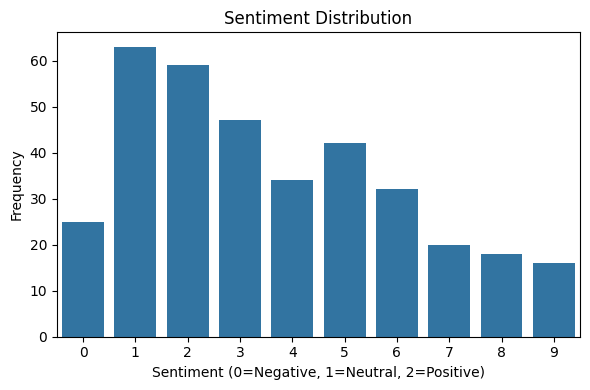

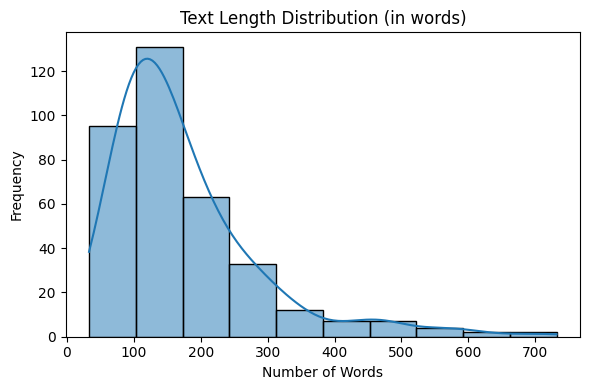

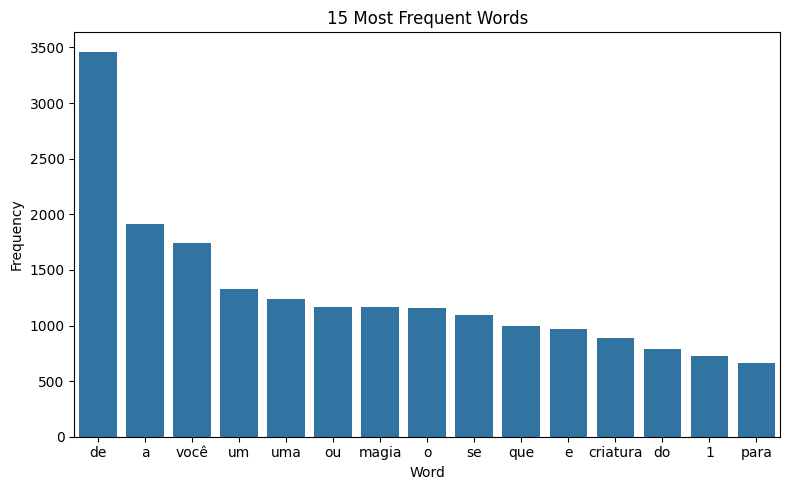

In [150]:


# TODO (s4hlo) check more relevant metrics

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='nivel')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0=Negative, 1=Neutral, 2=Positive)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

df["text_length"] = df["texto"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6, 4))
sns.histplot(df["text_length"], bins=10, kde=True)
plt.title("Text Length Distribution (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

all_words = [word for text in df["texto"] for word in tokenize(text)]
word_freq = Counter(all_words).most_common(15)
words, freqs = zip(*word_freq)

plt.figure(figsize=(8, 5))
sns.barplot(y=list(freqs), x=list(words),)
plt.title("15 Most Frequent Words")
plt.ylabel("Frequency")
plt.xlabel("Word")
plt.tight_layout()
plt.show()

In [152]:
import spacy
import numpy as np
import umap

nlp = spacy.load("pt_core_news_md")

df["embedding"] = df["texto"].apply(lambda x: nlp(x).vector)

X = np.vstack(df["embedding"].values)
y = df["target"].values

X_umap = umap.UMAP(random_state=42).fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y,  s=80)
plt.title("UMAP Document Embeddings (spaCy)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Sentimento (0=Neg, 1=Neutro, 2=Pos)")
plt.grid(True)
plt.tight_layout()
plt.show()

KeyError: 'target'

pos coleta de dados - tratamento

In [11]:
def make_lowercase(text: str) -> str:
    return text.lower()

def remove_excessive_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

pipeline_clean_text = Pipeline(
    steps=[
        ("make_lowercase", FunctionTransformer(lambda x: [make_lowercase(i) for i in x], validate=False)),
        ("remove_excessive_whitespace", FunctionTransformer(lambda x: [remove_excessive_whitespace(i) for i in x], validate=False)),
    ]
)

def safe_clean_text(x):
    try:
        return pipeline_clean_text.transform([str(x)])[0]
    except Exception:
        return x

df["selftext"] = df["selftext"].apply(safe_clean_text)

print("First 5 cleaned texts:")
for i in range(min(5, len(df))):
    print(f"\nText {i + 1}:")
    print(f"Content: {df['selftext'].iloc[i]}")



First 5 cleaned texts:

Text 1:
Content: adorei esse produto, me surpreendeu!

Text 2:
Content: não gostei da qualidade, deixou a desejar.

Text 3:
Content: é ok, nada demais também.

Text 4:
Content: o atendimento foi excelente, recomendo.

Text 5:
Content: demorou muito pra chegar, fiquei frustrado.


In [ ]:
# ------ split 1

# Display the first few rows of the DataFrame
# Drop the 'url' and 'id' columns from the DataFrame
df = df.drop(['url', 'id'], axis=1)

# Convert all text columns to lowercase
df['title'] = df['title'].str.lower()
df['selftext'] = df['selftext'].str.lower()

# Print the first 5 texts from the DataFrame
print("First 5 texts:")
for i in range(5):
    print(f"\nText {i+1}:")
    print(f"Title: {df['title'].iloc[i]}")
    print(f"Selftext: {df['selftext'].iloc[i]}")



# Get the most common words in selftext
from collections import Counter
import re

# Combine all selftext into one string and split into words
all_text = ' '.join(df['selftext'].dropna().astype(str))
words = re.findall(r'\w+', all_text.lower())

# Count word frequencies
word_counts = Counter(words)

# Get the 20 most common words
most_common = word_counts.most_common(20)

# Print the results
print("Most common words in selftext:")
for word, count in most_common:
    print(f"{word}: {count}")






df

First 5 texts:

Text 1:
Title: android app to strengthen attention/focus
Selftext: hey /r/adhd,

check out my simple android app: [attention exercise](https://market.android.com/details?id=com.racecarlabs.apps.android.attentionexercise)

it's just a series of simple touchscreen drawing exercises that, with practice, noticeably improve attention span and focus.  a session really shouldn't take more than a couple of minutes!

if you've heard of the book [delivered from distraction](http://www.amazon.com/delivered-distraction-getting-attention-disorder/dp/034544230x), the app is based on the exercises that dr. hallowell recommends in the book. 

writing code while managing my adhd symptoms hasn't been easy, but i hope this is an encouragement to you!  it felt really good to ship version 1.

if you have feature ideas or bug reports, i'd love to hear them!



on my roadmap:

* optional daily notifications (exercises work best with daily practice)
* tracking improvements
* making it prettier

,title,selftext,score,num_comments,created_utc,created_datetime
0,android app to strengthen attention/focus,"hey /r/adhd,\n\ncheck out my simple android ap...",6,7.0,1315014480.0,2011-09-03 01:48:00
1,does anyone here have experience with imipramine?,my doctor has suggested it for add with anxiet...,4,1.0,1315051084.0,2011-09-03 11:58:04
2,"new study shows that for people with adhd, \n""...",NaN,22,11.0,1315174374.0,2011-09-04 22:12:54
3,what does the adhd test look like?,i'm 21 and didn't know about adhd until recent...,6,10.0,1315239683.0,2011-09-05 16:21:23
4,are you guys good with maps and directions?,it seems like one thing i've always been reall...,0,0.0,1315317191.0,2011-09-06 13:53:11
...,...,...,...,...,...,...
336061,meds not working / lack of sleep to blame?,hi everyone\n\ni started taking mph 2 weeks ag...,1,2.0,1613046880.0,2021-02-11 12:34:40
336062,how to deal with friends who tell you to be ca...,[deleted],2,7.0,1613047275.0,2021-02-11 12:41:15
336063,"atomoxetine side effects were too harsh, appre...",hello everyone!\n\ni’ve been a part of this su...,1,2.0,1613047850.0,2021-02-11 12:50:50
336064,lto3 experiences,[removed],2,0.0,1613047852.0,2021-02-11 12:50:52
